# Parte 1. Concatenar CSVs

In [125]:
import os
import pandas as pd

base_dir = "outputs/por_chico"

dfs = []

for root, dirs, files in os.walk(base_dir):
    for fname in files:
        if not fname.lower().endswith(".csv"):
            continue
        if not fname.startswith("df_results_"):
            continue
            

        filepath = os.path.join(root, fname)

        name_no_ext = os.path.splitext(fname)[0]
        name_core = name_no_ext.replace("df_results_", "", 1)

        partes = name_core.split("-")

        nombre = partes[0] if len(partes) > 0 else ""
        numero_audio = partes[1] if len(partes) > 1 else ""
        nivel_socio = partes[2] if len(partes) > 2 else ""

        df = pd.read_csv(filepath)

        df["nombre"] = nombre
        df["numero_audio"] = numero_audio
        df["nivel_socio"] = nivel_socio
        df["archivo_origen"] = fname
        df["carpeta_origen"] = os.path.basename(root)

        cols_first = ["nombre", "numero_audio", "nivel_socio", "archivo_origen", "carpeta_origen"]
        other_cols = [c for c in df.columns if c not in cols_first]
        df = df[cols_first + other_cols]

        dfs.append(df)

df_resultados_concat = pd.concat(dfs, ignore_index=True)

print("Filas:", len(df_resultados_concat))
print("Chicos únicos:", df_resultados_concat["nombre"].nunique())

Filas: 3408002
Chicos únicos: 19


# Parte 2. Guardar concatenado

In [126]:
import os
import math

output_dir = "outputs/final_concats"
os.makedirs(output_dir, exist_ok=True)

# Límite seguro: 85 MB
max_size_bytes = 85 * 1024 * 1024

sample_n = min(10000, len(df_resultados_concat))

if sample_n == 0:
    print("DataFrame vacío.")
else:
    # --- Estimación inicial ---
    sample_df = df_resultados_concat.iloc[:sample_n]
    temp_path = os.path.join(output_dir, "_tmp_sample.csv")
    sample_df.to_csv(temp_path, index=False)
    sample_size = os.path.getsize(temp_path)
    os.remove(temp_path)

    bytes_per_row = sample_size / sample_n
    rows_per_file_est = max(1, int(max_size_bytes / bytes_per_row))

    print(f"Estimación inicial de filas por archivo: {rows_per_file_est}")

    start = 0
    part = 1
    total_rows = len(df_resultados_concat)

    while start < total_rows:
        end = min(start + rows_per_file_est, total_rows)

        # Primer intento
        chunk = df_resultados_concat.iloc[start:end]
        output_csv = os.path.join(output_dir, f"df_resultados_concat_part_{part}.csv")
        chunk.to_csv(output_csv, index=False)

        # Si se pasa, achicar hasta cumplir
        while os.path.getsize(output_csv) > max_size_bytes:
            os.remove(output_csv)

            # achicar un 10% cada vez
            new_rows = max(1, int((end - start) * 0.9))
            end = start + new_rows

            chunk = df_resultados_concat.iloc[start:end]
            chunk.to_csv(output_csv, index=False)

            # seguridad extra por si una sola fila fuera enorme
            if end == start + 1 and os.path.getsize(output_csv) > max_size_bytes:
                raise ValueError(
                    f"La fila en posición {start} sola supera el límite de {max_size_bytes} bytes."
                )

        final_size_mb = os.path.getsize(output_csv) / (1024 * 1024)
        print(
            f"Archivo {part}: filas {start} a {end-1} | "
            f"{end-start} filas | {final_size_mb:.2f} MB"
        )

        start = end
        part += 1

print("Archivos divididos correctamente.")

Estimación inicial de filas por archivo: 1272928
Archivo 1: filas 0 a 1145634 | 1145635 filas | 82.22 MB
Archivo 2: filas 1145635 a 2291269 | 1145635 filas | 84.69 MB
Archivo 3: filas 2291270 a 3408001 | 1116732 filas | 81.52 MB
Archivos divididos correctamente.


In [127]:
df = df_resultados_concat.copy()

# filas con al menos un NaN
df_nan = df[df.isna().any(axis=1)]

# chicos con NaN
chicos_con_nan = df_nan["nombre"].unique()

print("Chicos con al menos un NaN:")
print(chicos_con_nan)
print(f"\nCantidad: {len(chicos_con_nan)}")

Chicos con al menos un NaN:
[]

Cantidad: 0


# Análisis con todos los chicos

In [128]:
import numpy as np

df = df_resultados_concat.copy()

cols_elan = ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL"]
cols_diar = ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SPEECH"]

# SIL en Elan
df["Elan_SIL"] = (df[cols_elan].eq(0).all(axis=1)).astype(int)

# SIL en Diar
df["Diar_SIL"] = 1 - df["Diar_SPEECH"]

# Parte 4. Armar multilabel SIN ELE

In [129]:
labels = ["KCHI", "OCH", "MAL", "FEM", "SIL"]

y_true_multi = df[
    ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL", "Elan_SIL"]
].values

y_pred_multi = df[
    ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SIL"]
].values

# Parte 5. Multilabel confusion + report

In [130]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report
import pandas as pd
import numpy as np

# índices de las clases que forman SPEECH
speech_indices = [labels.index(l) for l in ["KCHI", "OCH", "MAL", "FEM"]]

# crear columna SPEECH
y_true_speech = (y_true_multi[:, speech_indices].sum(axis=1) > 0).astype(int)
y_pred_speech = (y_pred_multi[:, speech_indices].sum(axis=1) > 0).astype(int)

# agregar como nueva columna
y_true_multi = np.hstack([y_true_multi, y_true_speech.reshape(-1, 1)])
y_pred_multi = np.hstack([y_pred_multi, y_pred_speech.reshape(-1, 1)])

# agregar label
labels = labels + ["SPEECH"]

conf_matrix = multilabel_confusion_matrix(y_true_multi, y_pred_multi)

for i, label in enumerate(labels):
    print(f"\nMatriz para {label}:")
    print(conf_matrix[i])

print("\nReporte multilabel:")

# 🔽 CAMBIO ACÁ
report = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    zero_division=0,
    output_dict=True
)

df_report = pd.DataFrame(report).T

# pasar a porcentaje con 1 decimal
cols = ['precision', 'recall', 'f1-score']
df_report[cols] = (df_report[cols] * 100).round(1).astype(str) + "%"

print(df_report)


Matriz para KCHI:
[[2917413  157311]
 [  88300  244978]]

Matriz para OCH:
[[2993418  166471]
 [ 155485   92628]]

Matriz para MAL:
[[2516294  273821]
 [ 233469  384418]]

Matriz para FEM:
[[3049672  109115]
 [ 153352   95863]]

Matriz para SIL:
[[1081180  224068]
 [ 460099 1642655]]

Matriz para SPEECH:
[[1749356  353398]
 [ 313348  991900]]

Reporte multilabel:
             precision recall f1-score    support
KCHI             60.9%  73.5%    66.6%   333278.0
OCH              35.8%  37.3%    36.5%   248113.0
MAL              58.4%  62.2%    60.2%   617887.0
FEM              46.8%  38.5%    42.2%   249215.0
SIL              88.0%  78.1%    82.8%  2102754.0
SPEECH           73.7%  76.0%    74.8%  1305248.0
micro avg        72.9%  71.1%    72.0%  4856495.0
macro avg        60.6%  60.9%    60.5%  4856495.0
weighted avg     73.8%  71.1%    72.2%  4856495.0
samples avg      72.3%  73.6%    72.6%  4856495.0


## Análisis solo con los ACLEW 

In [131]:
import numpy as np
import pandas as pd
import re
from sklearn.metrics import multilabel_confusion_matrix, classification_report

# =========================
# 1) Copia y filtro de chicos
# =========================
df = df_resultados_concat.copy()

chicos_excluir = ["jeremiasc", "valentina", "brandona", "bautistad", "camilob"]

def extraer_chico_base(x):
    x = str(x).strip().lower()
    m = re.match(r"^(.*?)-a\d+-ns[mb]$", x)
    if m:
        return m.group(1)
    return x

df["chico"] = df["nombre"].apply(extraer_chico_base)

df = df[~df["chico"].isin(chicos_excluir)].copy()

print("Filas luego del filtro:", len(df))
print("Chicos excluidos que siguen presentes:", df["chico"].isin(chicos_excluir).sum())

# =========================
# 2) Definir orden base de etiquetas
# =========================
# IMPORTANTE:
# Este orden se usa para columnas, arrays, matrices y reporte.
# No cambiarlo en un lugar sin cambiarlo en todos.
labels_base = ["KCHI", "OCH", "MAL", "FEM"]

cols_elan = [f"Elan_{label}" for label in labels_base]
cols_diar = [f"Diar_{label}" for label in labels_base]

# =========================
# 3) Chequeo de columnas necesarias
# =========================
cols_necesarias = cols_elan + cols_diar + ["Diar_SPEECH", "nombre"]

faltantes = [col for col in cols_necesarias if col not in df.columns]

if faltantes:
    raise KeyError(f"Faltan estas columnas en df_resultados_concat: {faltantes}")

# =========================
# 4) Asegurar valores numéricos 0/1
# =========================
# Esto evita problemas si alguna columna viene como string, bool, NaN, etc.
for col in cols_elan + cols_diar + ["Diar_SPEECH"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Opcional: revisar NaN antes de calcular métricas
cols_metricas = cols_elan + cols_diar + ["Diar_SPEECH"]

filas_con_nan = df[cols_metricas].isna().any(axis=1).sum()
print("Filas con NaN en columnas de métricas:", filas_con_nan)

# Si hay NaN, las elimino para que sklearn no falle ni calcule mal
df = df.dropna(subset=cols_metricas).copy()

# Convertir a enteros
for col in cols_metricas:
    df[col] = df[col].astype(int)

print("Filas luego de eliminar NaN en métricas:", len(df))

# =========================
# 5) Crear SIL
# =========================
# Elan_SIL = 1 si no hay ninguna etiqueta de habla en ELAN
df["Elan_SIL"] = (df[cols_elan].eq(0).all(axis=1)).astype(int)

# Diar_SIL = 1 si Diar_SPEECH es 0
df["Diar_SIL"] = (1 - df["Diar_SPEECH"]).astype(int)

# =========================
# 6) Armar matrices multilabel base
#    Orden: KCHI, OCH, MAL, FEM
# =========================
y_true_base = df[cols_elan].values
y_pred_base = df[cols_diar].values

print("\nOrden de columnas ELAN usado:")
print(cols_elan)

print("\nOrden de columnas DIAR usado:")
print(cols_diar)

# =========================
# 7) Crear SPEECH a partir de KCHI/OCH/MAL/FEM
# =========================
# SPEECH = 1 si hay al menos una etiqueta activa entre KCHI/OCH/MAL/FEM
y_true_speech = (y_true_base.sum(axis=1) > 0).astype(int)
y_pred_speech = (y_pred_base.sum(axis=1) > 0).astype(int)

# Chequeo opcional contra Diar_SPEECH original
diferencias_speech = (y_pred_speech != df["Diar_SPEECH"].values).sum()
print("\nDiferencias entre SPEECH recalculado desde Diar_* y Diar_SPEECH original:", diferencias_speech)

# =========================
# 8) Construir multilabel final
#    SIN SIL
#    Orden final: KCHI, OCH, MAL, FEM, SPEECH
# =========================
y_true_multi = np.column_stack([
    y_true_base,
    y_true_speech
])

y_pred_multi = np.column_stack([
    y_pred_base,
    y_pred_speech
])

labels = labels_base + ["SPEECH"]

print("\nshape y_true_multi:", y_true_multi.shape)
print("shape y_pred_multi:", y_pred_multi.shape)
print("labels:", labels)

# =========================
# 9) Matrices de confusión multilabel
# =========================
conf_matrix = multilabel_confusion_matrix(y_true_multi, y_pred_multi)

for i, label in enumerate(labels):
    print(f"\nMatriz para {label}:")
    print(conf_matrix[i])

# =========================
# 10) Reporte multilabel
# =========================
print("\nReporte multilabel:")

report = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    zero_division=0,
    output_dict=True
)

df_report = pd.DataFrame(report).T

# =========================
# 10.1) Support en muestras, tiempo y % sobre total
# =========================
# support = cantidad de muestras/frames positivos por clase
# 1 muestra/frame = 0.01 segundos

total_muestras = len(df)
frame_duration_sec = 0.01

def frames_a_min_seg(frames):
    segundos = int(round(frames * frame_duration_sec))
    minutos = segundos // 60
    segundos_restantes = segundos % 60
    return f"{minutos}:{segundos_restantes:02d}"

df_report["support_muestras"] = df_report["support"].round(0).astype(int)

df_report["support_tiempo"] = df_report["support_muestras"].apply(frames_a_min_seg)

df_report["support_%_total"] = (
    df_report["support_muestras"] / total_muestras * 100
).round(1).astype(str) + "%"

# =========================
# 10.2) Formatear métricas
# =========================
cols_porcentaje = ["precision", "recall", "f1-score"]

df_report[cols_porcentaje] = (
    df_report[cols_porcentaje] * 100
).round(1).astype(str) + "%"

# Orden final de columnas
df_report = df_report[
    [
        "precision",
        "recall",
        "f1-score",
        "support_muestras",
        "support_tiempo",
        "support_%_total"
    ]
]

# Guardar en Excel
df_report.to_excel("outputs/reporte_multilabel_support_tiempo_porcentaje.xlsx", index=True)

print(df_report)

Filas luego del filtro: 3408002
Chicos excluidos que siguen presentes: 0
Filas con NaN en columnas de métricas: 0
Filas luego de eliminar NaN en métricas: 3408002

Orden de columnas ELAN usado:
['Elan_KCHI', 'Elan_OCH', 'Elan_MAL', 'Elan_FEM']

Orden de columnas DIAR usado:
['Diar_KCHI', 'Diar_OCH', 'Diar_MAL', 'Diar_FEM']

Diferencias entre SPEECH recalculado desde Diar_* y Diar_SPEECH original: 304103

shape y_true_multi: (3408002, 5)
shape y_pred_multi: (3408002, 5)
labels: ['KCHI', 'OCH', 'MAL', 'FEM', 'SPEECH']

Matriz para KCHI:
[[2917413  157311]
 [  88300  244978]]

Matriz para OCH:
[[2993418  166471]
 [ 155485   92628]]

Matriz para MAL:
[[3049672  109115]
 [ 153352   95863]]

Matriz para FEM:
[[2516294  273821]
 [ 233469  384418]]

Matriz para SPEECH:
[[1749356  353398]
 [ 313348  991900]]

Reporte multilabel:
             precision recall f1-score  support_muestras support_tiempo  \
KCHI             60.9%  73.5%    66.6%            333278          55:33   
OCH              3

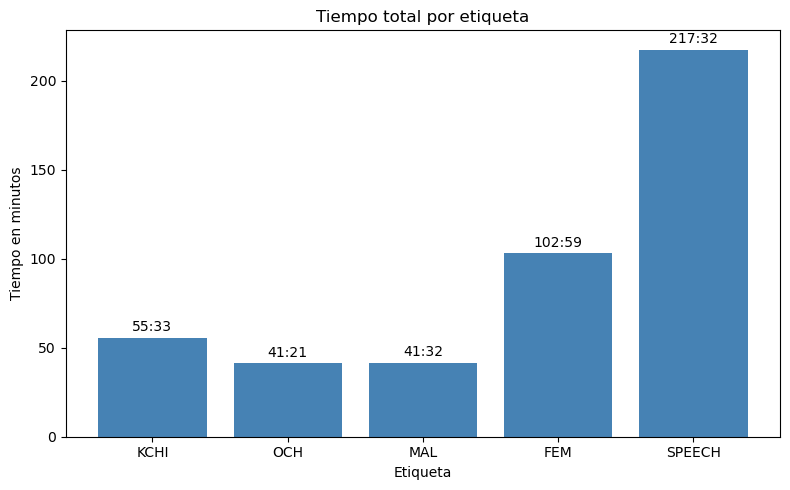

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# 1) Copiar reporte
# =========================
df_report_plot = df_report.copy()  # cambiar df_report por el nombre real de tu dataframe

# =========================
# 2) Quedarse solo con etiquetas reales
# =========================
etiquetas = ["KCHI", "OCH", "MAL", "FEM", "SPEECH"]

df_tiempos = df_report_plot.loc[etiquetas].copy()

# =========================
# 3) Convertir support_tiempo MM:SS a minutos
# =========================
def tiempo_a_minutos(x):
    x = str(x).strip()
    minutos, segundos = x.split(":")
    return int(minutos) + int(segundos) / 60

df_tiempos["tiempo_minutos"] = df_tiempos["support_tiempo"].apply(tiempo_a_minutos)

# =========================
# 4) Graficar
# =========================
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(8, 5))

plt.bar(
    df_tiempos.index,
    df_tiempos["tiempo_minutos"],
    color="steelblue"
)

plt.title("Tiempo total por etiqueta")
plt.xlabel("Etiqueta")
plt.ylabel("Tiempo en minutos")

# Etiquetas arriba de cada barra en formato MM:SS
for i, row in enumerate(df_tiempos.itertuples()):
    plt.text(
        i,
        row.tiempo_minutos + 2,
        row.support_tiempo,
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "tiempo_total_por_etiqueta.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(output_dir, "final_concats/comparacion_tiempo.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Gráficos ,recall, precision, f1 score

,Tipo,Precisión,Recall,F1-score,support_muestras,support_tiempo,support_%_total
0,KCHI,60.9,73.5,66.6,333278,55:33,9.8%
1,OCH,35.8,37.3,36.5,248113,41:21,7.3%
2,MAL,46.8,38.5,42.2,249215,41:32,7.3%
3,FEM,58.4,62.2,60.2,617887,102:59,18.1%
4,SPEECH,73.7,76.0,74.8,1305248,217:32,38.3%


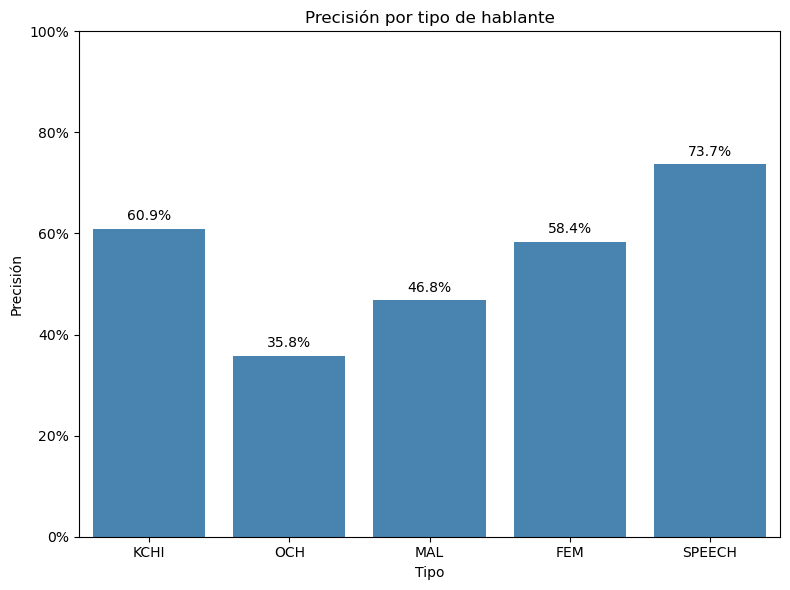

Gráfico guardado en: outputs/final_concats/precision_multilabel.png


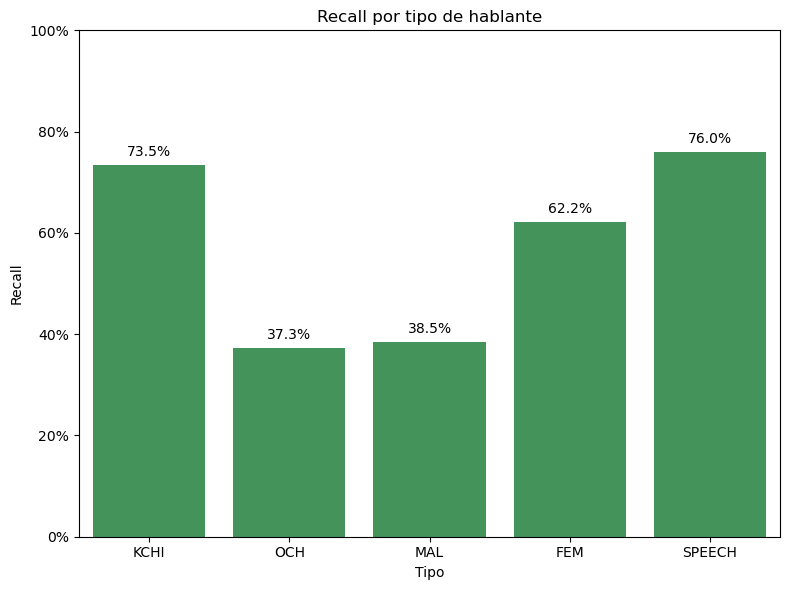

Gráfico guardado en: outputs/final_concats/recall_multilabel.png


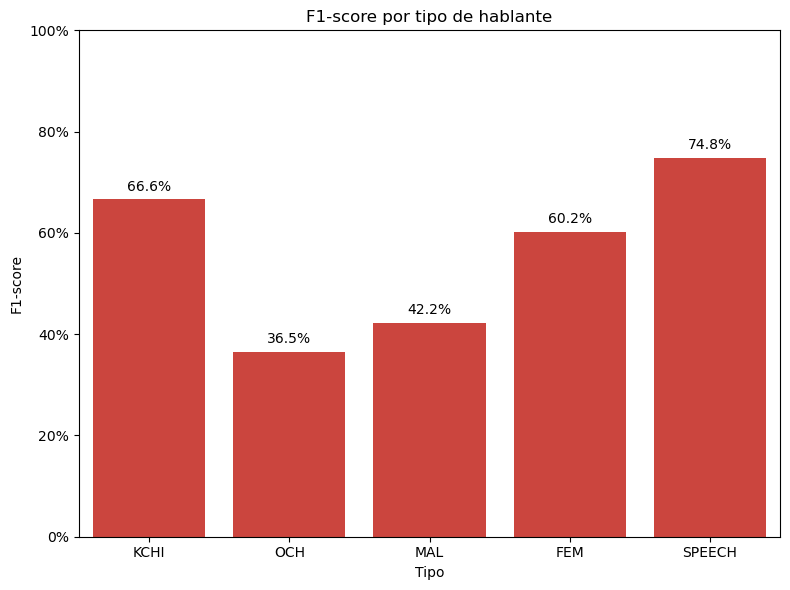

Gráfico guardado en: outputs/final_concats/f1_multilabel.png


In [134]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# =========================
# 1) Preparar dataframe para gráficos
# =========================

os.makedirs("outputs/final_concats", exist_ok=True)

etiquetas = ["KCHI", "OCH", "MAL", "FEM", "SPEECH"]

df_metrics = df_report.loc[etiquetas].copy()

df_metrics = df_metrics.reset_index().rename(columns={"index": "Tipo"})

cols_metricas = ["precision", "recall", "f1-score"]

for col in cols_metricas:
    df_metrics[col] = (
        df_metrics[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .astype(float)
    )

df_metrics = df_metrics.rename(columns={
    "precision": "Precisión",
    "recall": "Recall",
    "f1-score": "F1-score"
})

orden = ["KCHI", "OCH", "MAL", "FEM", "SPEECH"]

df_metrics["Tipo"] = pd.Categorical(
    df_metrics["Tipo"],
    categories=orden,
    ordered=True
)

df_metrics = df_metrics.sort_values("Tipo").copy()

display(df_metrics)


# =========================
# 2) Función para graficar métricas
# =========================

def plot_metrica_multilabel(df_metrics, metrica, color, filename):
    
    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        data=df_metrics,
        x="Tipo",
        y=metrica,
        color=color,
        errorbar=None
    )

    plt.title(f"{metrica} por tipo de hablante")
    plt.xlabel("Tipo")
    plt.ylabel(metrica)
    plt.ylim(0, 100)

    ax.yaxis.set_major_formatter(
        mtick.PercentFormatter(xmax=100, decimals=0)
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=4,
            fontsize=10
        )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Gráfico guardado en: {filename}")


# =========================
# 3) Colores por métrica
# =========================

color_precision = sns.color_palette("Blues", 5)[3]
color_recall = sns.color_palette("Greens", 5)[3]
color_f1 = sns.color_palette("Reds", 5)[3]


# =========================
# 4) Graficar
# =========================

plot_metrica_multilabel(
    df_metrics=df_metrics,
    metrica="Precisión",
    color=color_precision,
    filename="outputs/final_concats/precision_multilabel.png"
)

plot_metrica_multilabel(
    df_metrics=df_metrics,
    metrica="Recall",
    color=color_recall,
    filename="outputs/final_concats/recall_multilabel.png"
)

plot_metrica_multilabel(
    df_metrics=df_metrics,
    metrica="F1-score",
    color=color_f1,
    filename="outputs/final_concats/f1_multilabel.png"
)

## ANÁLISIS POR NIVEL SOCIOECONÓMICO


In [103]:
df_frames = (
    df_resultados_concat
    .groupby(["nombre", "numero_audio", "nivel_socio"])
    .size()
    .reset_index(name="n_frames")
)

# df_frames.sort_values("n_frames")

In [104]:
chicos_excluir = ["jeremiasc", "valentina", "brandona"]

df_frames = (
    df_resultados_concat[
        ~df_resultados_concat["nombre"].isin(chicos_excluir)
    ]
    .groupby(["nombre", "numero_audio", "nivel_socio"])
    .size()
    .reset_index(name="n_frames")
)

# df_frames = df_frames.sort_values("n_frames")


In [105]:
df_frames = (
    df_resultados_concat
    .groupby(["nombre", "numero_audio", "nivel_socio"])
    .size()
    .reset_index(name="n_frames")
)

# 1 frame = 0.01 segundos
df_frames["segundos"] = df_frames["n_frames"] * 0.01
df_frames["minutos"] = df_frames["segundos"] / 60

# formato mm:ss
df_frames["tiempo_mm_ss"] = pd.to_timedelta(df_frames["segundos"], unit="s").astype(str)

df_frames = df_frames.sort_values("n_frames")

df_frames

,nombre,numero_audio,nivel_socio,n_frames,segundos,minutos,tiempo_mm_ss
18,verag,a2,nsm,168000,1680.00,28.000000,0 days 00:28:00
16,ummaq,a2,nsb,180000,1800.00,30.000000,0 days 00:30:00
15,manuelc,a2,nsm,180000,1800.00,30.000000,0 days 00:30:00
14,lucior,a2,nsm,180000,1800.00,30.000000,0 days 00:30:00
13,lucasyoelp,a2,nsb,180000,1800.00,30.000000,0 days 00:30:00
12,lisandroh,a2,nsm,180000,1800.00,30.000000,0 days 00:30:00
11,julietap,a1,nsm,180000,1800.00,30.000000,0 days 00:30:00
10,gaell,a2,nsb,180000,1800.00,30.000000,0 days 00:30:00
17,valentinos,a1,nsb,180000,1800.00,30.000000,0 days 00:30:00
0,alma,a1,nsb,180000,1800.00,30.000000,0 days 00:30:00


In [106]:
df = df_resultados_concat.copy()

df_nsb = df[df["nivel_socio"] == "nsb"]
df_nsm = df[df["nivel_socio"] == "nsm"]

In [107]:
labels = ['KCHI', 'OCH', 'FEM', 'MAL', 'SIL']

y_true_nsb = df_nsb[
    ['Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_SIL']
].values

y_pred_nsb = df_nsb[
    ['Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SIL']
].values


y_true_nsm = df_nsm[
    ['Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_SIL']
].values

y_pred_nsm = df_nsm[
    ['Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SIL']
].values

In [108]:
speech_idx = [0, 1, 2, 3]  # KCHI, OCH, FEM, MAL

def agregar_speech(y):
    speech = (y[:, speech_idx].sum(axis=1) > 0).astype(int)
    return np.hstack([y, speech.reshape(-1, 1)])

y_true_nsb = agregar_speech(y_true_nsb)
y_pred_nsb = agregar_speech(y_pred_nsb)

y_true_nsm = agregar_speech(y_true_nsm)
y_pred_nsm = agregar_speech(y_pred_nsm)

labels_full = labels + ["SPEECH"]

In [109]:
print(df.columns.tolist())

['nombre', 'numero_audio', 'nivel_socio', 'archivo_origen', 'carpeta_origen', 'Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_ELE', 'Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SPEECH', 'Elan_SPEECH', 'Elan_SIL', 'Diar_SIL']


## Report multilabel por nivel socio y por audio

In [110]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import os

FRAME_SEC = 0.01  # 1 frame = 0.01 segundos

# =========================
# 1) Definir columnas base
# =========================

# Orden consistente con el reporte multilabel principal
labels_base = ["KCHI", "OCH", "MAL", "FEM"]

cols_elan = [f"Elan_{label}" for label in labels_base]
cols_diar = [f"Diar_{label}" for label in labels_base]

labels_full = labels_base + ["SPEECH"]


# =========================
# 2) Función para armar y_true/y_pred multilabel
#    recalculando SPEECH
# =========================

def construir_y_multi(df_grupo, cols_elan, cols_diar):
    y_true_base = df_grupo[cols_elan].values
    y_pred_base = df_grupo[cols_diar].values

    # SPEECH = 1 si hay al menos una etiqueta activa
    # entre KCHI, OCH, MAL, FEM
    y_true_speech = (y_true_base.sum(axis=1) > 0).astype(int)
    y_pred_speech = (y_pred_base.sum(axis=1) > 0).astype(int)

    y_true_multi = np.column_stack([
        y_true_base,
        y_true_speech
    ])

    y_pred_multi = np.column_stack([
        y_pred_base,
        y_pred_speech
    ])

    return y_true_multi, y_pred_multi


# =========================
# 3) Función para reporte
# =========================

def generar_report_con_support_minutos(y_true, y_pred, labels_full):
    report = classification_report(
        y_true,
        y_pred,
        target_names=labels_full,
        zero_division=0,
        output_dict=True
    )

    df_report = pd.DataFrame(report).T

    # Support en frames
    df_report["support_muestras"] = df_report["support"].round(0).astype(int)

    # Support en minutos
    df_report["support_minutos"] = df_report["support"] * FRAME_SEC / 60
    df_report["support_minutos"] = df_report["support_minutos"].round(2)

    # Support en formato mm:ss
    df_report["support_tiempo"] = df_report["support"].apply(
        lambda x: f"{int((x * FRAME_SEC) // 60):02d}:{int((x * FRAME_SEC) % 60):02d}"
    )

    # Métricas en porcentaje
    df_report["precision"] = (df_report["precision"] * 100).round(1)
    df_report["recall"] = (df_report["recall"] * 100).round(1)
    df_report["f1-score"] = (df_report["f1-score"] * 100).round(1)

    # Limpieza de columna original support
    df_report = df_report.drop(columns=["support"])

    return df_report


# =========================
# 4) Reportes por nivel_socio + numero_audio
# =========================

def generar_reportes_por_nivel_y_audio(
    df,
    cols_elan,
    cols_diar,
    labels_full,
    nivel_col="nivel_socio",
    audio_col="numero_audio"
):
    reportes = {}

    for (nivel, numero_audio), df_grupo in df.groupby([nivel_col, audio_col]):

        y_true, y_pred = construir_y_multi(
            df_grupo=df_grupo,
            cols_elan=cols_elan,
            cols_diar=cols_diar
        )

        df_report = generar_report_con_support_minutos(
            y_true=y_true,
            y_pred=y_pred,
            labels_full=labels_full
        )

        # Agrego información del grupo
        df_report.insert(0, "nivel_socio", nivel)
        df_report.insert(1, "numero_audio", numero_audio)
        df_report.insert(2, "frames_totales_grupo", len(df_grupo))
        df_report.insert(
            3,
            "minutos_totales_grupo",
            round(len(df_grupo) * FRAME_SEC / 60, 2)
        )

        nombre_reporte = f"{nivel}_audio_{numero_audio}"
        reportes[nombre_reporte] = df_report

    return reportes


reportes = generar_reportes_por_nivel_y_audio(
    df=df,
    cols_elan=cols_elan,
    cols_diar=cols_diar,
    labels_full=labels_full,
    nivel_col="nivel_socio",
    audio_col="numero_audio"
)


# =========================
# 5) Mostrar reportes por nivel_socio + numero_audio
# =========================

for nombre, df_report in reportes.items():
    print(f"\n=== {nombre.upper()} ===")
    display(df_report)


# =========================
# 6) Reportes solo por nivel_socio
# =========================

def generar_reportes_por_nivel_socio(
    df,
    cols_elan,
    cols_diar,
    labels_full,
    nivel_col="nivel_socio"
):
    reportes = {}

    for nivel, df_grupo in df.groupby(nivel_col):

        y_true, y_pred = construir_y_multi(
            df_grupo=df_grupo,
            cols_elan=cols_elan,
            cols_diar=cols_diar
        )

        df_report = generar_report_con_support_minutos(
            y_true=y_true,
            y_pred=y_pred,
            labels_full=labels_full
        )

        # Agrego información del grupo
        df_report.insert(0, "nivel_socio", nivel)
        df_report.insert(1, "frames_totales_grupo", len(df_grupo))
        df_report.insert(
            2,
            "minutos_totales_grupo",
            round(len(df_grupo) * FRAME_SEC / 60, 2)
        )

        nombre_reporte = f"{nivel}_total"
        reportes[nombre_reporte] = df_report

    return reportes


reportes_nivel_socio = generar_reportes_por_nivel_socio(
    df=df,
    cols_elan=cols_elan,
    cols_diar=cols_diar,
    labels_full=labels_full,
    nivel_col="nivel_socio"
)


# =========================
# 7) Mostrar reportes solo por nivel_socio
# =========================

for nombre, df_report in reportes_nivel_socio.items():
    print(f"\n=== {nombre.upper()} ===")
    display(df_report)


# =========================
# 8) Exportar todo a Excel
# =========================

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "classification_report_multilabel_por_nivel_socio_y_audio.xlsx"
)

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:

    # Reportes por nivel_socio + numero_audio
    for nombre, df_report in reportes.items():
        sheet_name = str(nombre)[:31]
        df_report.to_excel(writer, sheet_name=sheet_name)

    # Reportes solo por nivel_socio
    for nombre, df_report in reportes_nivel_socio.items():
        sheet_name = str(nombre)[:31]
        df_report.to_excel(writer, sheet_name=sheet_name)

print(f"Excel exportado en: {output_path}")


=== NSB_AUDIO_A1 ===


,nivel_socio,numero_audio,frames_totales_grupo,minutos_totales_grupo,precision,recall,f1-score,support_muestras,support_minutos,support_tiempo
KCHI,nsb,a1,720000,120.0,52.5,67.1,58.9,60846,10.14,10:08
OCH,nsb,a1,720000,120.0,42.3,46.8,44.4,75332,12.56,12:33
MAL,nsb,a1,720000,120.0,38.7,37.7,38.2,53903,8.98,08:59
FEM,nsb,a1,720000,120.0,57.7,57.9,57.8,167797,27.97,27:57
SPEECH,nsb,a1,720000,120.0,70.1,73.2,71.6,320477,53.41,53:24
micro avg,nsb,a1,720000,120.0,59.8,63.1,61.4,678355,113.06,113:03
macro avg,nsb,a1,720000,120.0,52.3,56.5,54.2,678355,113.06,113:03
weighted avg,nsb,a1,720000,120.0,59.9,63.1,61.4,678355,113.06,113:03
samples avg,nsb,a1,720000,120.0,27.8,28.3,27.8,678355,113.06,113:03



=== NSB_AUDIO_A2 ===


,nivel_socio,numero_audio,frames_totales_grupo,minutos_totales_grupo,precision,recall,f1-score,support_muestras,support_minutos,support_tiempo
KCHI,nsb,a2,900000,150.0,52.9,73.4,61.5,87087,14.51,14:30
OCH,nsb,a2,900000,150.0,44.5,38.9,41.5,90068,15.01,15:00
MAL,nsb,a2,900000,150.0,41.9,27.0,32.8,61615,10.27,10:16
FEM,nsb,a2,900000,150.0,46.5,46.3,46.4,150972,25.16,25:09
SPEECH,nsb,a2,900000,150.0,72.6,70.5,71.5,347761,57.96,57:57
micro avg,nsb,a2,900000,150.0,59.2,58.4,58.8,737503,122.92,122:55
macro avg,nsb,a2,900000,150.0,51.7,51.2,50.7,737503,122.92,122:55
weighted avg,nsb,a2,900000,150.0,59.0,58.4,58.3,737503,122.92,122:55
samples avg,nsb,a2,900000,150.0,22.2,22.6,22.2,737503,122.92,122:55



=== NSM_AUDIO_A1 ===


...


=== NSB_TOTAL ===


,nivel_socio,frames_totales_grupo,minutos_totales_grupo,precision,recall,f1-score,support_muestras,support_minutos,support_tiempo
KCHI,nsb,1620000,270.0,52.8,70.8,60.4,147933,24.66,24:39
OCH,nsb,1620000,270.0,43.4,42.5,42.9,165400,27.57,27:34
MAL,nsb,1620000,270.0,40.1,32.0,35.6,115518,19.25,19:15
FEM,nsb,1620000,270.0,52.4,52.4,52.4,318769,53.13,53:07
SPEECH,nsb,1620000,270.0,71.4,71.8,71.6,668238,111.37,111:22
micro avg,nsb,1620000,270.0,59.5,60.6,60.1,1415858,235.98,235:58
macro avg,nsb,1620000,270.0,52.0,53.9,52.6,1415858,235.98,235:58
weighted avg,nsb,1620000,270.0,59.3,60.6,59.8,1415858,235.98,235:58
samples avg,nsb,1620000,270.0,24.7,25.2,24.7,1415858,235.98,235:58



=== NSM_TOTAL ===


,nivel_socio,frames_totales_grupo,minutos_totales_grupo,precision,recall,f1-score,support_muestras,support_minutos,support_tiempo
KCHI,nsm,1788002,298.0,68.8,75.7,72.1,185345,30.89,30:53
OCH,nsm,1788002,298.0,23.0,27.0,24.8,82713,13.79,13:47
MAL,nsm,1788002,298.0,52.3,44.1,47.8,133697,22.28,22:16
FEM,nsm,1788002,298.0,64.0,72.7,68.1,299118,49.85,49:51
SPEECH,nsm,1788002,298.0,76.1,80.4,78.2,637010,106.17,106:10
micro avg,nsm,1788002,298.0,66.7,71.1,68.8,1337883,222.98,222:58
macro avg,nsm,1788002,298.0,56.8,60.0,58.2,1337883,222.98,222:58
weighted avg,nsm,1788002,298.0,66.7,71.1,68.7,1337883,222.98,222:58
samples avg,nsm,1788002,298.0,25.3,25.5,25.2,1337883,222.98,222:58


Excel exportado en: outputs\classification_report_multilabel_por_nivel_socio_y_audio.xlsx


In [111]:
from sklearn.metrics import classification_report
import pandas as pd
import os

FRAME_SEC = 0.01  # 1 frame = 0.01 segundos

# =========================
# 1) Definir columnas
# =========================

labels_full = ["KCHI", "OCH", "FEM", "MAL", "SPEECH"]

elan_cols = [
    "Elan_KCHI",
    "Elan_OCH",
    "Elan_FEM",
    "Elan_MAL",
    "Elan_SPEECH"
]

diar_cols = [
    "Diar_KCHI",
    "Diar_OCH",
    "Diar_FEM",
    "Diar_MAL",
    "Diar_SPEECH"
]


# =========================
# 2) Separar NSB y NSM
# =========================

df_nsb = df[df["nivel_socio"] == "nsb"].copy()
df_nsm = df[df["nivel_socio"] == "nsm"].copy()

y_true_nsb = df_nsb[elan_cols].values
y_pred_nsb = df_nsb[diar_cols].values

y_true_nsm = df_nsm[elan_cols].values
y_pred_nsm = df_nsm[diar_cols].values


# =========================
# 3) Classification reports
# =========================

report_nsb = classification_report(
    y_true_nsb,
    y_pred_nsb,
    target_names=labels_full,
    output_dict=True,
    zero_division=0
)

report_nsm = classification_report(
    y_true_nsm,
    y_pred_nsm,
    target_names=labels_full,
    output_dict=True,
    zero_division=0
)


# =========================
# 4) Comparación F1 NSB vs NSM
# =========================

df_comp = pd.DataFrame({
    "nsb_f1": {
        k: v["f1-score"]
        for k, v in report_nsb.items()
        if k in labels_full
    },
    "nsm_f1": {
        k: v["f1-score"]
        for k, v in report_nsm.items()
        if k in labels_full
    },
})

df_comp["diff"] = df_comp["nsm_f1"] - df_comp["nsb_f1"]


# =========================
# 5) Support en minutos
# =========================

support_nsb = pd.Series({
    k: v["support"]
    for k, v in report_nsb.items()
    if k in labels_full
})

support_nsm = pd.Series({
    k: v["support"]
    for k, v in report_nsm.items()
    if k in labels_full
})

df_comp["nsb_support_minutos"] = support_nsb * FRAME_SEC / 60
df_comp["nsm_support_minutos"] = support_nsm * FRAME_SEC / 60

df_comp["diff_support_minutos"] = (
    df_comp["nsm_support_minutos"] - df_comp["nsb_support_minutos"]
)


# =========================
# 6) Formato
# =========================

df_comp["nsb_f1"] = df_comp["nsb_f1"].round(4)
df_comp["nsm_f1"] = df_comp["nsm_f1"].round(4)
df_comp["diff"] = df_comp["diff"].round(4)

df_comp["nsb_support_minutos"] = df_comp["nsb_support_minutos"].round(2)
df_comp["nsm_support_minutos"] = df_comp["nsm_support_minutos"].round(2)
df_comp["diff_support_minutos"] = df_comp["diff_support_minutos"].round(2)


# =========================
# 7) Mostrar
# =========================

display(df_comp)


# =========================
# 8) Exportar a Excel
# =========================

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "comparacion_f1_nsb_nsm_con_diff_tiempo.xlsx"
)

df_comp.to_excel(output_path, sheet_name="comparacion")

print(f"Excel exportado en: {output_path}")

,nsb_f1,nsm_f1,diff,nsb_support_minutos,nsm_support_minutos,diff_support_minutos
KCHI,0.6045,0.7209,0.1165,24.66,30.89,6.24
OCH,0.4294,0.2483,-0.1812,27.57,13.79,-13.78
FEM,0.5241,0.6806,0.1565,53.13,49.85,-3.28
MAL,0.3556,0.4782,0.1225,19.25,22.28,3.03
SPEECH,0.7329,0.7873,0.0544,111.37,106.17,-5.20


Excel exportado en: outputs\comparacion_f1_nsb_nsm_con_diff_tiempo.xlsx


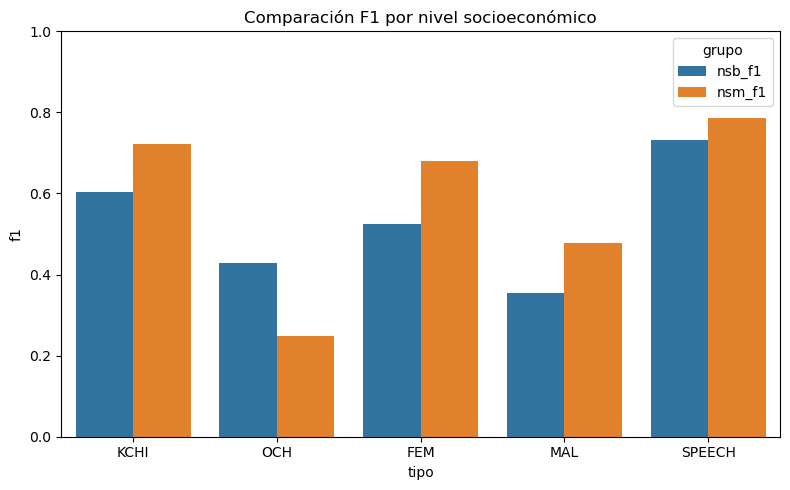

In [124]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_comp.reset_index().rename(columns={"index": "tipo"})

df_plot_melt = df_plot.melt(
    id_vars="tipo",
    value_vars=["nsb_f1", "nsm_f1"],
    var_name="grupo",
    value_name="f1"
)

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(8, 5))

sns.barplot(data=df_plot_melt, x="tipo", y="f1", hue="grupo")

plt.title("Comparación F1 por nivel socioeconómico")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "final_concats/comparacion_f1_nivel_socioeconomico.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [113]:
from sklearn.metrics import classification_report
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

FRAME_SEC = 0.01

# =========================
# 1) Definir columnas
# =========================

labels_full = ["KCHI", "OCH", "FEM", "MAL", "SPEECH"]

elan_cols = [
    "Elan_KCHI",
    "Elan_OCH",
    "Elan_FEM",
    "Elan_MAL",
    "Elan_SPEECH"
]

diar_cols = [
    "Diar_KCHI",
    "Diar_OCH",
    "Diar_FEM",
    "Diar_MAL",
    "Diar_SPEECH"
]


# =========================
# 2) Armar dataframe de F1 por nivel_socio + numero_audio
# =========================

resultados_audio = []

for (nivel_socio, numero_audio), df_grupo in df.groupby(["nivel_socio", "numero_audio"]):

    y_true = df_grupo[elan_cols].values
    y_pred = df_grupo[diar_cols].values

    report = classification_report(
        y_true,
        y_pred,
        target_names=labels_full,
        output_dict=True,
        zero_division=0
    )

    for tipo in labels_full:
        resultados_audio.append({
            "nivel_socio": nivel_socio,
            "numero_audio": numero_audio,
            "grupo_audio": f"{nivel_socio}_audio_{numero_audio}",
            "tipo": tipo,
            "f1": report[tipo]["f1-score"],
            "support_minutos": report[tipo]["support"] * FRAME_SEC / 60
        })

df_f1_audio = pd.DataFrame(resultados_audio)

df_f1_audio["f1"] = df_f1_audio["f1"].round(4)
df_f1_audio["support_minutos"] = df_f1_audio["support_minutos"].round(2)

display(df_f1_audio)

,nivel_socio,numero_audio,grupo_audio,tipo,f1,support_minutos
0,nsb,a1,nsb_audio_a1,KCHI,0.5890,10.14
1,nsb,a1,nsb_audio_a1,OCH,0.4445,12.56
2,nsb,a1,nsb_audio_a1,FEM,0.5782,27.97
3,nsb,a1,nsb_audio_a1,MAL,0.3818,8.98
4,nsb,a1,nsb_audio_a1,SPEECH,0.7364,53.41
5,nsb,a2,nsb_audio_a2,KCHI,0.6148,14.51
6,nsb,a2,nsb_audio_a2,OCH,0.4153,15.01
7,nsb,a2,nsb_audio_a2,FEM,0.4638,25.16
8,nsb,a2,nsb_audio_a2,MAL,0.3281,10.27
9,nsb,a2,nsb_audio_a2,SPEECH,0.7296,57.96


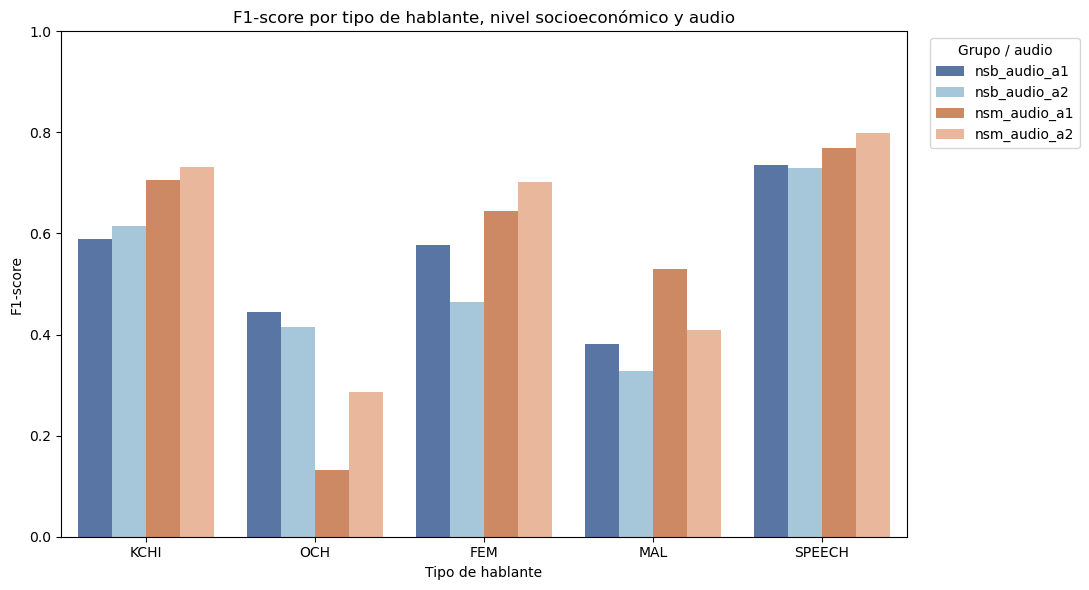

In [123]:
# =========================
# 3) Gráfico único: 4 barras por etiqueta
# con gama de colores por nivel_socio
# =========================

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

orden_hue = [
    "nsb_audio_a1",
    "nsb_audio_a2",
    "nsm_audio_a1",
    "nsm_audio_a2"
]

palette = {
    "nsb_audio_a1": "#4C72B0",  # azul oscuro
    "nsb_audio_a2": "#9ECAE1",  # azul claro
    "nsm_audio_a1": "#DD8452",  # naranja oscuro
    "nsm_audio_a2": "#F6B48F",  # naranja claro
}

plt.figure(figsize=(11, 6))

sns.barplot(
    data=df_f1_audio,
    x="tipo",
    y="f1",
    hue="grupo_audio",
    hue_order=orden_hue,
    palette=palette
)

plt.title("F1-score por tipo de hablante, nivel socioeconómico y audio")
plt.xlabel("Tipo de hablante")
plt.ylabel("F1-score")
plt.ylim(0, 1)

plt.legend(
    title="Grupo / audio",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "final_concats/f1_por_tipo_nivel_socio_y_audio_colores_por_nivel.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Parte 6. Multilabel → Single label

## REPORTE SINGLE LABEL

In [115]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# orden single-label correcto
labels_single = ["KCHI", "OCH", "MAL", "FEM", "SIL"]

# construir matrices base
y_true_base = df[
    ["Elan_KCHI", "Elan_OCH", "Elan_MAL", "Elan_FEM", "Elan_SIL"]
].values

y_pred_base = df[
    ["Diar_KCHI", "Diar_OCH", "Diar_MAL", "Diar_FEM", "Diar_SIL"]
].values

def multilabel_exclusivo_a_singlelabel(y_multilabel):
    single_labels = []
    for row in y_multilabel:
        indices = np.where(row == 1)[0]
        if len(indices) == 0:
            single_labels.append(-1)
        elif len(indices) == 1:
            single_labels.append(indices[0])
        else:
            # si hubiera más de una clase positiva en una fila "exclusiva",
            # tomar la primera y dejar advertencia conceptual
            single_labels.append(indices[0])
    return np.array(single_labels)

y_true = multilabel_exclusivo_a_singlelabel(y_true_base)
y_pred = multilabel_exclusivo_a_singlelabel(y_pred_base)

valid_indices = (y_true != -1) & (y_pred != -1)
y_true = y_true[valid_indices]
y_pred = y_pred[valid_indices]

print("\nReporte single-label:")

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(labels_single))),
    target_names=labels_single,
    zero_division=0,
    output_dict=True
)

df_report_single = pd.DataFrame(report).T

cols = ["precision", "recall", "f1-score"]
df_report_single[cols] = (df_report_single[cols] * 100).round(1).astype(str) + "%"

print(df_report_single)


Reporte single-label:
             precision recall f1-score       support
KCHI             60.9%  77.9%    68.3%  3.146110e+05
OCH              35.9%  30.8%    33.2%  2.098830e+05
MAL              44.1%  45.2%    44.6%  1.947400e+05
FEM              54.2%  63.9%    58.6%  4.774300e+05
SIL              88.7%  82.0%    85.2%  1.961296e+06
accuracy         73.2%  73.2%    73.2%  7.316499e-01
macro avg        56.7%  59.9%    58.0%  3.157960e+06
weighted avg     74.4%  73.2%    73.5%  3.157960e+06


# Parte 7. Matriz de confusión global 

## PRECISIÓN

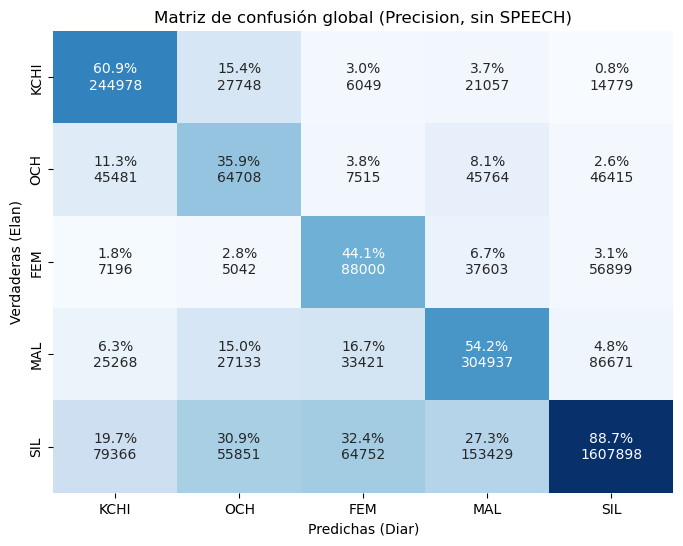

In [116]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

labels_idx = list(range(len(labels)))

# matriz de conteos
cm_counts = confusion_matrix(y_true, y_pred, labels=labels_idx)

# precision: normalizada por columnas
cm_precision = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="pred")

# sacar SPEECH solo del gráfico
if "SPEECH" in labels:
    idx_speech = labels.index("SPEECH")
    idx_keep = [i for i in range(len(labels)) if i != idx_speech]

    cm_counts_plot = cm_counts[np.ix_(idx_keep, idx_keep)]
    cm_precision_plot = cm_precision[np.ix_(idx_keep, idx_keep)]
    labels_plot = [labels[i] for i in idx_keep]
else:
    cm_counts_plot = cm_counts
    cm_precision_plot = cm_precision
    labels_plot = labels

cm_counts_df = pd.DataFrame(cm_counts_plot, index=labels_plot, columns=labels_plot)
cm_precision_df = pd.DataFrame(cm_precision_plot, index=labels_plot, columns=labels_plot)

annot = (
    (cm_precision_df * 100).round(1).astype(str)
    + "%"
    + "\n"
    + cm_counts_df.astype(int).astype(str)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_precision_df,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=False
)

plt.title("Matriz de confusión global (Precision, sin SPEECH)")
plt.ylabel("Verdaderas (Elan)")
plt.xlabel("Predichas (Diar)")

plt.savefig(
    "outputs/final_concats/matriz_confusion_global_precision_sin_speech.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## RECALL 

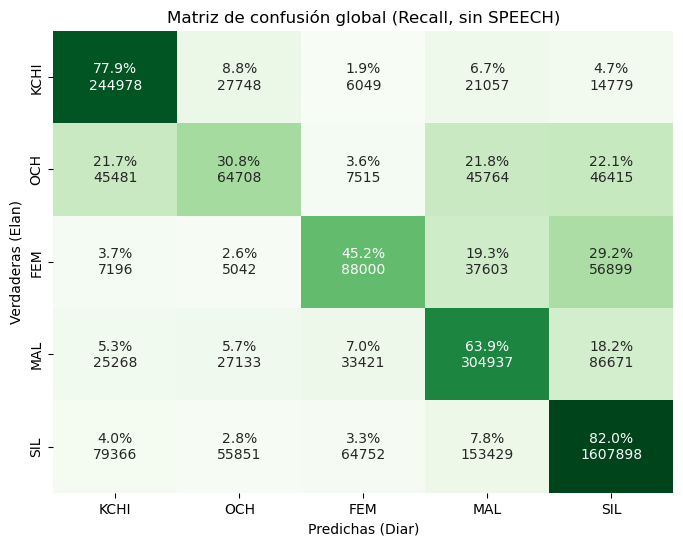

In [117]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

labels_idx = list(range(len(labels)))

# matriz de conteos
cm_counts = confusion_matrix(y_true, y_pred, labels=labels_idx)

# recall: normalizada por filas
cm_recall = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="true")

# sacar SPEECH solo del gráfico
if "SPEECH" in labels:
    idx_speech = labels.index("SPEECH")
    idx_keep = [i for i in range(len(labels)) if i != idx_speech]

    cm_counts_plot = cm_counts[np.ix_(idx_keep, idx_keep)]
    cm_recall_plot = cm_recall[np.ix_(idx_keep, idx_keep)]
    labels_plot = [labels[i] for i in idx_keep]
else:
    cm_counts_plot = cm_counts
    cm_recall_plot = cm_recall
    labels_plot = labels

cm_counts_df = pd.DataFrame(cm_counts_plot, index=labels_plot, columns=labels_plot)
cm_recall_df = pd.DataFrame(cm_recall_plot, index=labels_plot, columns=labels_plot)

annot = (
    (cm_recall_df * 100).round(1).astype(str)
    + "%"
    + "\n"
    + cm_counts_df.astype(int).astype(str)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_recall_df,
    annot=annot,
    fmt="",
    cmap="Greens",
    cbar=False
)

plt.title("Matriz de confusión global (Recall, sin SPEECH)")
plt.ylabel("Verdaderas (Elan)")
plt.xlabel("Predichas (Diar)")

plt.savefig(
    "outputs/final_concats/matriz_confusion_global_recall_sin_speech.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Parte 10. Ranking por chico

In [119]:
df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv", low_memory=False)

print(df.columns.tolist())

['Tipo', 'Precisión', 'Recall', 'F1-score', 'Support', 'name', 'archivo_origen', 'path', 'nombre_base', 'corpus', 'ns_code', 'Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_ELE', 'Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SPEECH', 'Elan_SPEECH', 'Elan_SIL', 'Diar_SIL']


In [120]:
import pandas as pd
import re

tipos_para_ranking = ["FEM", "MAL", "KCHI", "OCH"]

df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv", low_memory=False)

# Limpiar posibles espacios en nombres de columnas
df.columns = df.columns.str.strip()

# =========================
# 0) Limpieza
# =========================
df["F1-score"] = pd.to_numeric(df["F1-score"], errors="coerce")
df["Support"] = pd.to_numeric(df["Support"], errors="coerce")

df_rank = df[df["Tipo"].isin(tipos_para_ranking)].copy()

# Extraer nombre base del chico desde strings tipo:
# alma-a1-nsb -> alma
# verag-a2-nsm -> verag
def extraer_chico_base(x):
    x = str(x).strip().lower()
    m = re.match(r"^(.*?)-a\d+-ns[mb]$", x)
    if m:
        return m.group(1)
    return x

df_rank["chico"] = df_rank["name"].apply(extraer_chico_base)

# =========================
# 1) Promedio por chico y tipo
# =========================
df_por_tipo = (
    df_rank
    .groupby(["chico", "Tipo"], as_index=False)
    .agg(
        f1_promedio=("F1-score", "mean"),
        support_tipo=("Support", "sum")
    )
)

# =========================
# 2) Pivotear F1
# =========================
df_pivot = df_por_tipo.pivot(
    index="chico",
    columns="Tipo",
    values="f1_promedio"
).reset_index()

df_pivot = df_pivot.rename(columns={
    "FEM": "f1_FEM",
    "MAL": "f1_MAL",
    "KCHI": "f1_KCHI",
    "OCH": "f1_OCH"
})

# Asegurar columnas aunque falte alguna
for col in ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]:
    if col not in df_pivot.columns:
        df_pivot[col] = pd.NA

# =========================
# 3) Promedio total
# =========================
columnas_f1 = ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]
df_pivot["f1_promedio_total"] = df_pivot[columnas_f1].mean(axis=1)

# =========================
# 4) Metadata + Support por chico
# =========================
meta = (
    df_rank
    .groupby("chico", as_index=False)
    .agg(
        ns_code=("ns_code", lambda s: s.dropna().iloc[0] if not s.dropna().empty else pd.NA),
        support_total=("Support", "sum")
    )
)

# Cada muestra equivale a 0.01 segundos
meta["tiempo_total_segundos"] = meta["support_total"] * 0.01
meta["tiempo_total_minutos"] = meta["tiempo_total_segundos"] / 60

df_final = df_pivot.merge(meta, on="chico", how="left")

# =========================
# 5) Map manual de corpus por chico
# =========================
map_corpus = {
    "alma": "raw_ROS",
    "amparol": "raw_ROS",
    "angelinap": "raw_ROS",
    "bautista": "segunda-vuelta/random",
    "bautistad": "segunda-vuelta/random",
    "biancak": "raw_ROS_HV",
    "brandona": "segunda-vuelta/highVol",
    "camilob": "segunda-vuelta/random",
    "camilop": "raw_ROS_HV",
    "dantec": "raw_ROS",
    "dantep": "raw_ROS_HV",
    "dianag": "raw_ROS_HV",
    "florl": "segunda-vuelta/random",
    "francescam": "raw_ROS_HV",
    "franciscop": "raw_ROS_HV",
    "gaell": "raw_ROS",
    "jeremiasc": "segunda-vuelta/highVol",
    "julietap": "raw_ROS_HV",
    "lisandroh": "raw_ROS",
    "lucasyoelp": "raw_ROS_HV",
    "lucior": "raw_ROS",
    "manuelc": "raw_ROS",
    "ummaq": "raw_ROS",
    "valentina": "segunda-vuelta/highVol",
    "valentinos": "raw_ROS",
    "verag": "raw_ROS_HV",
}

df_final["corpus"] = df_final["chico"].map(map_corpus)

# =========================
# 6) Ranking
# =========================
df_final = df_final.sort_values("f1_promedio_total", ascending=False).reset_index(drop=True)
df_final["ranking"] = df_final.index + 1

# =========================
# 7) Orden final
# =========================
df_final = df_final[
    [
        "ranking",
        "chico",
        "corpus",
        "ns_code",
        "support_total",
        "tiempo_total_segundos",
        "tiempo_total_minutos",
        "f1_promedio_total",
        "f1_FEM",
        "f1_MAL",
        "f1_KCHI",
        "f1_OCH"
    ]
]

# =========================
# 8) Revisar faltantes
# =========================
faltan_corpus = df_final[df_final["corpus"].isna()]
if not faltan_corpus.empty:
    print("\nNombres sin corpus asignado:")
    print(faltan_corpus[["chico"]].drop_duplicates().sort_values("chico"))

# =========================
# 9) Guardar
# =========================
df_final.to_csv(
    "outputs/ranking_f1_por_chico.csv",
    index=False,
    encoding="utf-8-sig"
)

print(df_final.head(10))

   ranking       chico      corpus ns_code  support_total  \
0        1        alma     raw_ROS     nsb        74387.0   
1        2       verag  raw_ROS_HV     nsm        66585.0   
2        3  franciscop  raw_ROS_HV     nsm        69203.0   
3        4     amparol     raw_ROS     nsb       132095.0   
4        5      dantep  raw_ROS_HV     nsm        88111.0   
5        6      dianag  raw_ROS_HV     nsb        97073.0   
6        7   lisandroh     raw_ROS     nsm       103441.0   
7        8      lucior     raw_ROS     nsm       118072.0   
8        9   angelinap     raw_ROS     nsm        58886.0   
9       10    julietap  raw_ROS_HV     nsm        59454.0   

   tiempo_total_segundos  tiempo_total_minutos  f1_promedio_total    f1_FEM  \
0                 743.87             12.397833           0.567843  0.624738   
1                 665.85             11.097500           0.544746  0.819251   
2                 692.03             11.533833           0.513893  0.744271   
3           

In [121]:
df_final

,ranking,chico,corpus,ns_code,support_total,tiempo_total_segundos,tiempo_total_minutos,f1_promedio_total,f1_FEM,f1_MAL,f1_KCHI,f1_OCH
0,1,alma,raw_ROS,nsb,74387.0,743.87,12.397833,0.567843,0.624738,0.464171,0.642668,0.539797
1,2,verag,raw_ROS_HV,nsm,66585.0,665.85,11.097500,0.544746,0.819251,0.562983,0.796750,0.000000
2,3,franciscop,raw_ROS_HV,nsm,69203.0,692.03,11.533833,0.513893,0.744271,0.483493,0.827808,0.000000
3,4,amparol,raw_ROS,nsb,132095.0,1320.95,22.015833,0.502191,0.564282,0.426217,0.565517,0.452747
4,5,dantep,raw_ROS_HV,nsm,88111.0,881.11,14.685167,0.492102,0.730624,0.666058,0.571727,0.000000
5,6,dianag,raw_ROS_HV,nsb,97073.0,970.73,16.178833,0.475131,0.673355,0.272314,0.550755,0.404101
6,7,lisandroh,raw_ROS,nsm,103441.0,1034.41,17.240167,0.469679,0.614277,0.409740,0.495047,0.359653
7,8,lucior,raw_ROS,nsm,118072.0,1180.72,19.678667,0.466533,0.679651,0.376634,0.597606,0.212243
8,9,angelinap,raw_ROS,nsm,58886.0,588.86,9.814333,0.464117,0.573500,0.445049,0.627462,0.210458
9,10,julietap,raw_ROS_HV,nsm,59454.0,594.54,9.909000,0.460615,0.685825,0.326197,0.830437,0.000000
